In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# check to see if data loaded properly
df = pd.read_csv("lc_2016_2017.csv")
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,112435993,NaN,2300,2300,2300.0,36 months,12.62,77.08,C,C1,...,0.0,NaN,1.0,2.0,2315.0,55.0,7100.0,1.0,0.0,2.0
1,112290210,NaN,16000,16000,16000.0,60 months,12.62,360.95,C,C1,...,11078.0,69.0,3.0,5.0,1962.0,94.0,31900.0,0.0,6.0,1.0
2,112436985,NaN,6025,6025,6025.0,36 months,15.05,209.01,C,C4,...,0.0,NaN,1.0,2.0,1950.0,45.0,27700.0,1.0,5.0,3.0
3,112439006,NaN,20400,20400,20400.0,36 months,9.44,652.91,B,B1,...,53566.0,95.0,1.0,2.0,4240.0,60.0,46900.0,1.0,1.0,1.0
4,112438929,NaN,13000,13000,13000.0,36 months,11.99,431.73,B,B5,...,8466.0,72.0,0.0,1.0,2996.0,78.0,7800.0,0.0,0.0,0.0


In [100]:
i = 0
for col in df.columns:
    print(i,col)
    i+=1

0 id
1 member_id
2 loan_amnt
3 funded_amnt
4 funded_amnt_inv
5 term
6 int_rate
7 installment
8 grade
9 sub_grade
10 emp_title
11 emp_length
12 home_ownership
13 annual_inc
14 verification_status
15 issue_d
16 loan_status
17 pymnt_plan
18 desc
19 purpose
20 title
21 zip_code
22 addr_state
23 dti
24 delinq_2yrs
25 earliest_cr_line
26 inq_last_6mths
27 mths_since_last_delinq
28 mths_since_last_record
29 open_acc
30 pub_rec
31 revol_bal
32 revol_util
33 total_acc
34 initial_list_status
35 out_prncp
36 out_prncp_inv
37 total_pymnt
38 total_pymnt_inv
39 total_rec_prncp
40 total_rec_int
41 total_rec_late_fee
42 recoveries
43 collection_recovery_fee
44 last_pymnt_d
45 last_pymnt_amnt
46 next_pymnt_d
47 last_credit_pull_d
48 collections_12_mths_ex_med
49 mths_since_last_major_derog
50 policy_code
51 application_type
52 annual_inc_joint
53 dti_joint
54 verification_status_joint
55 acc_now_delinq
56 tot_coll_amt
57 tot_cur_bal
58 open_acc_6m
59 open_il_12m
60 open_il_24m
61 mths_since_rcnt_il
62 

In [110]:
df_yes = df.loc[df['pymnt_plan'] == "y"]
df_no = df.loc[df['pymnt_plan'] == "n"]
df_members = df[df["member_id"].isna()]
df_nonmems = df[~df["member_id"].isna()]
# all rows are of nonmembers
print(df_nonmems.shape)

(0, 72)

Text(0.5, 1.0, 'Payment Plan vs No Payment Plan')

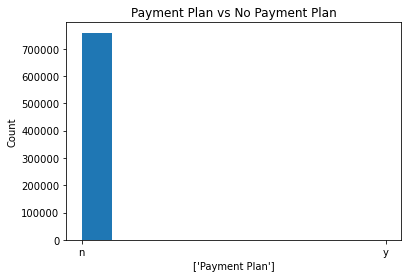

In [82]:
# As we can see there are many people without a payment plan
plt.hist(df["pymnt_plan"])
plt.xlabel(["Payment Plan"])
plt.ylabel("Count")
plt.title("Payment Plan vs No Payment Plan")

<AxesSubplot:xlabel='loan_amnt', ylabel='Density'>

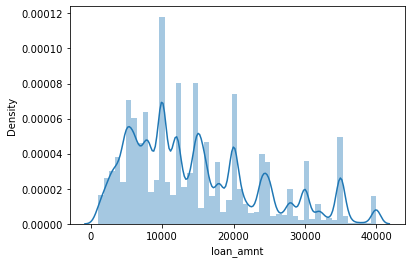

In [97]:
sns.distplot(df["loan_amnt"])

In [112]:
#pd.melt() takes wide data and converts it to long data
#pd.melt() will merge columns together
#id_vars tells pd.melt() what columns to leave as is
df["annual_inc"]

0         10000.0
1         94000.0
2         46350.0
3         44000.0
4         85000.0
           ...   
759333    38000.0
759334    32640.0
759335    47000.0
759336    87800.0
759337    65000.0
Name: annual_inc, Length: 759338, dtype: float64

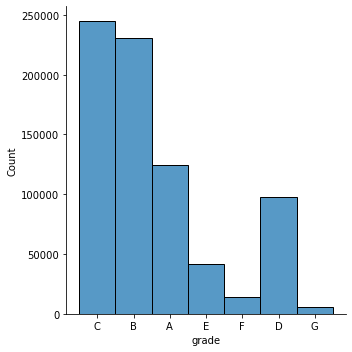

In [103]:
sns.displot(data=df['grade'])

C:\Users\there\AppData\Local\Continuum\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='installment', ylabel='Density'>

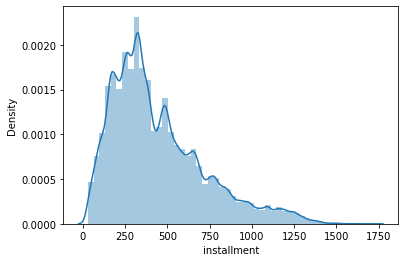

In [104]:
sns.distplot(df["installment"])

C:\Users\there\AppData\Local\Continuum\anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='annual_inc'>

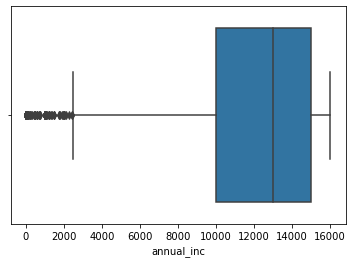

In [120]:
dfIncome = df[df["annual_inc"] < 1000]
sns.boxplot(dfIncome["annual_inc"])